# **TUGAS BESAR DATA MINING**



---


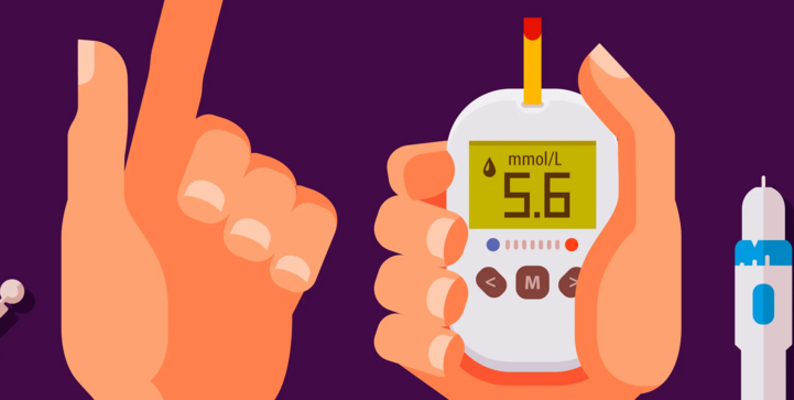

# DATA UNDERSTANDING

---

## STUDI KASUS: 


Dalam Studi Kasus kali ini kita akan melakukan analisis menggunakan metode K-Means Clustering (Unsupervised Learn) dan Logistic Regression (Supervise Learn)

### 📄 Informasi Dataset

Dataset ini memberikan gambaran umum yang luas tentang berbagai jenis diabetes, termasuk Diabetes yang Diinduksi Steroid, Diabetes Melitus Neonatal (NDM), Pradiabetes, Diabetes Tipe 1, dan Sindrom Wolfram. Data ini mencakup berbagai atribut medis, genetik, dan gaya hidup yang penting untuk memahami faktor-faktor yang berkontribusi terhadap diabetes.

Key Features:
1. Target: The type of diabetes or prediabetic condition.
2. Genetic Markers: Indicators of genetic predisposition to diabetes.
3. Autoantibodies: Presence of autoantibodies commonly associated with autoimmune diabetes.
4. Family History: Information on whether there is a known family history of diabetes.
5. Environmental Factors: Details about environmental influences that may contribute to diabetes.
6. Insulin Levels: Measured insulin levels in patients.
7. Age and BMI: Demographic information including age and Body Mass Index.
8. Physical Activity and Dietary Habits: Lifestyle factors that could influence diabetes risk.
9. Blood Pressure
10. Cholesterol Levels
11. Waist Circumference
12. Blood Glucose Levels
13. Ethnicity
14. Socioeconomic Factors
15. Smoking Status
16. Alcohol Consumption
17. Glucose Tolerance Test
18. History of PCOS
19. Previous Gestational Diabetes
20. Pregnancy History
21. Weight Gain During Pregnancy
22. Pancreatic Health
23. Pulmonary Function
24. Cystic Fibrosis Diagnosis
25. Steroid Use History
26. Genetic Testing
27. Neurological Assessments
28. Liver Function Tests
29. Digestive Enzyme Levels
30. Urine Test
31. Birth Weight
32. Early Onset Symptoms

### 1. Load Data

In [31]:
import pandas as pd

In [32]:
df = pd.read_csv('diabetes_dataset00.csv')

In [33]:
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah baris: 70000
Jumlah kolom: 34


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Target                         70000 non-null  object
 1   Genetic Markers                70000 non-null  object
 2   Autoantibodies                 70000 non-null  object
 3   Family History                 70000 non-null  object
 4   Environmental Factors          70000 non-null  object
 5   Insulin Levels                 70000 non-null  int64 
 6   Age                            70000 non-null  int64 
 7   BMI                            70000 non-null  int64 
 8   Physical Activity              70000 non-null  object
 9   Dietary Habits                 70000 non-null  object
 10  Blood Pressure                 70000 non-null  int64 
 11  Cholesterol Levels             70000 non-null  int64 
 12  Waist Circumference            70000 non-null  int64 
 13  B

In [35]:
print(df.dtypes)

Target                           object
Genetic Markers                  object
Autoantibodies                   object
Family History                   object
Environmental Factors            object
Insulin Levels                    int64
Age                               int64
BMI                               int64
Physical Activity                object
Dietary Habits                   object
Blood Pressure                    int64
Cholesterol Levels                int64
Waist Circumference               int64
Blood Glucose Levels              int64
Ethnicity                        object
Socioeconomic Factors            object
Smoking Status                   object
Alcohol Consumption              object
Glucose Tolerance Test           object
History of PCOS                  object
Previous Gestational Diabetes    object
Pregnancy History                object
Weight Gain During Pregnancy      int64
Pancreatic Health                 int64
Pulmonary Function                int64


In [36]:
df.describe()

,Insulin Levels,Age,BMI,Blood Pressure,Cholesterol Levels,Waist Circumference,Blood Glucose Levels,Weight Gain During Pregnancy,Pancreatic Health,Pulmonary Function,Neurological Assessments,Digestive Enzyme Levels,Birth Weight
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,21.607443,32.020700,24.782943,111.339543,194.867200,35.051657,160.701657,15.496414,47.564243,70.264671,1.804157,46.420529,3097.061071
std,10.785852,21.043173,6.014236,19.945000,44.532466,6.803461,48.165547,9.633096,19.984683,11.965600,0.680154,19.391089,713.837300
min,5.000000,0.000000,12.000000,60.000000,100.000000,20.000000,80.000000,0.000000,10.000000,30.000000,1.000000,10.000000,1500.000000
25%,13.000000,14.000000,20.000000,99.000000,163.000000,30.000000,121.000000,7.000000,32.000000,63.000000,1.000000,31.000000,2629.000000
50%,19.000000,31.000000,25.000000,113.000000,191.000000,34.000000,152.000000,16.000000,46.000000,72.000000,2.000000,48.000000,3103.000000
75%,28.000000,49.000000,29.000000,125.000000,225.000000,39.000000,194.000000,22.000000,64.000000,79.000000,2.000000,61.000000,3656.250000
max,49.000000,79.000000,39.000000,149.000000,299.000000,54.000000,299.000000,39.000000,99.000000,89.000000,3.000000,99.000000,4499.000000


In [37]:
df.head()

,Target,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,...,Pulmonary Function,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms
0,Steroid-Induced Diabetes,Positive,Negative,No,Present,40,44,38,High,Healthy,...,76,No,No,Positive,3,Normal,56,Ketones Present,2629,No
1,Neonatal Diabetes Mellitus (NDM),Positive,Negative,No,Present,13,1,17,High,Healthy,...,60,Yes,No,Negative,1,Normal,28,Glucose Present,1881,Yes
2,Prediabetic,Positive,Positive,Yes,Present,27,36,24,High,Unhealthy,...,80,Yes,No,Negative,1,Abnormal,55,Ketones Present,3622,Yes
3,Type 1 Diabetes,Negative,Positive,No,Present,8,7,16,Low,Unhealthy,...,89,Yes,No,Positive,2,Abnormal,60,Ketones Present,3542,No
4,Wolfram Syndrome,Negative,Negative,Yes,Present,17,10,17,High,Healthy,...,41,No,No,Positive,1,Normal,24,Protein Present,1770,No


In [38]:
df['Target'].value_counts()

Target
MODY                                          5553
Secondary Diabetes                            5479
Cystic Fibrosis-Related Diabetes (CFRD)       5464
Type 1 Diabetes                               5446
Neonatal Diabetes Mellitus (NDM)              5408
Wolcott-Rallison Syndrome                     5400
Type 2 Diabetes                               5397
Prediabetic                                   5376
Gestational Diabetes                          5344
Type 3c Diabetes (Pancreatogenic Diabetes)    5320
Wolfram Syndrome                              5315
Steroid-Induced Diabetes                      5275
LADA                                          5223
Name: count, dtype: int64

#### Melihat Proporsi Diabetes

In [39]:
print(df['Target'].value_counts())
print(df['Target'].value_counts(normalize=True)) 

Target
MODY                                          5553
Secondary Diabetes                            5479
Cystic Fibrosis-Related Diabetes (CFRD)       5464
Type 1 Diabetes                               5446
Neonatal Diabetes Mellitus (NDM)              5408
Wolcott-Rallison Syndrome                     5400
Type 2 Diabetes                               5397
Prediabetic                                   5376
Gestational Diabetes                          5344
Type 3c Diabetes (Pancreatogenic Diabetes)    5320
Wolfram Syndrome                              5315
Steroid-Induced Diabetes                      5275
LADA                                          5223
Name: count, dtype: int64
Target
MODY                                          0.079329
Secondary Diabetes                            0.078271
Cystic Fibrosis-Related Diabetes (CFRD)       0.078057
Type 1 Diabetes                               0.077800
Neonatal Diabetes Mellitus (NDM)              0.077257
Wolcott-Rallison Syndr

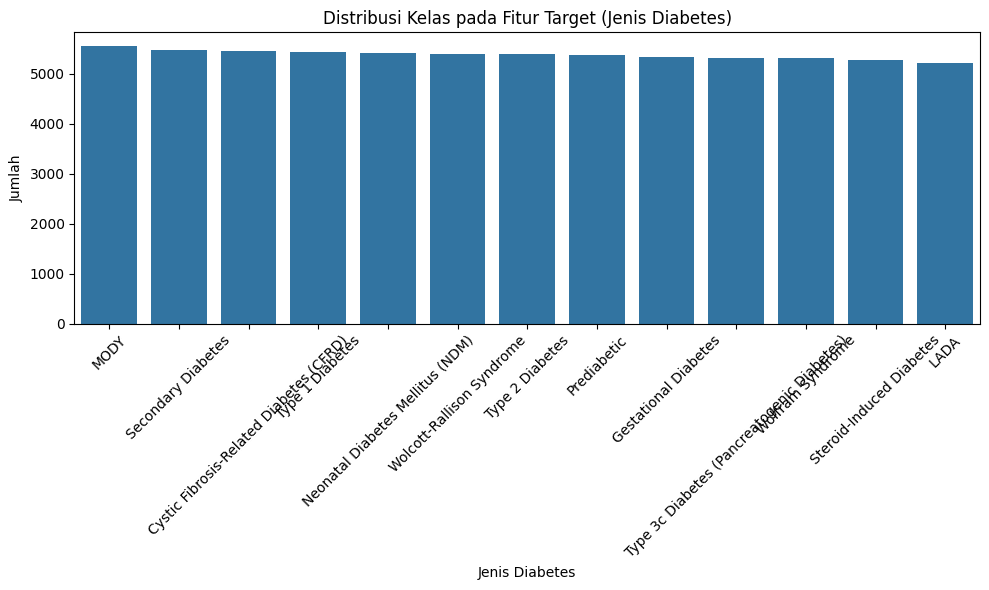

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.countplot(x='Target', data=df, order=df['Target'].value_counts().index)
plt.title("Distribusi Kelas pada Fitur Target (Jenis Diabetes)")
plt.xticks(rotation=45)
plt.xlabel("Jenis Diabetes")
plt.ylabel("Jumlah")
plt.tight_layout()
plt.show()

#### Menguji Korelasi Antar Fitur Numerik

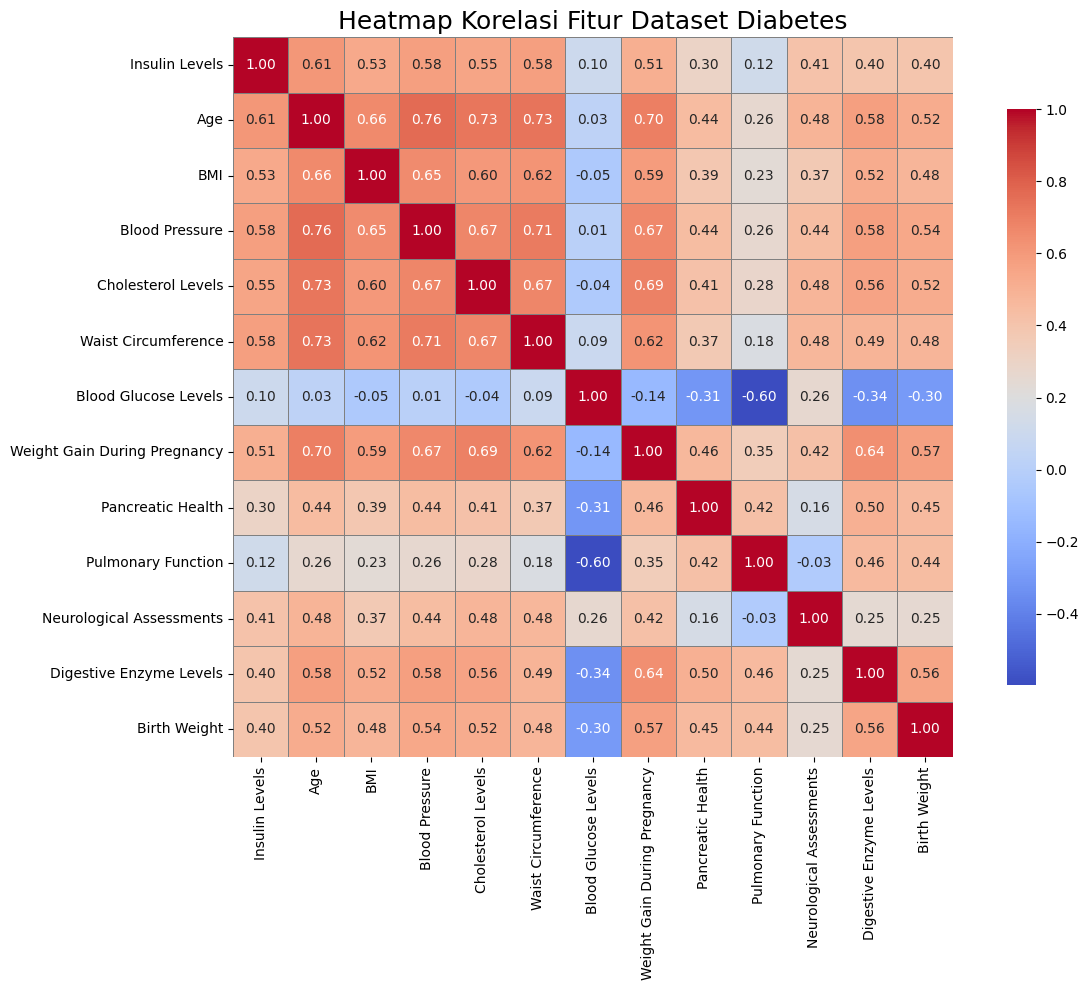

In [41]:
# Buat correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Ukuran plot besar agar tidak terpotong
plt.figure(figsize=(13, 10))

# Heatmap
sns.heatmap(
    correlation_matrix,
    annot=True, fmt=".2f", cmap='coolwarm',
    linewidths=0.5, linecolor='gray',
    square=True, cbar_kws={"shrink": 0.8}
)

plt.title("Heatmap Korelasi Fitur Dataset Diabetes", fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Menguji Korelasi Fitur Kategorikal 

In [42]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

from scipy.stats import chi2_contingency

# Mengiterasi kolom kategorikal dan melakukan uji Chi-Square dengan target
for col in categorical_columns:
    if col != 'Target':  # Menghindari menguji Target dengan dirinya sendiri
        contingency_table = pd.crosstab(df[col], df['Target'])
        
        # Melakukan uji Chi-Square
        chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
        
        print(f'Uji Chi-Square untuk {col} dengan Target:')
        print('Chi-Square Stat:', chi2_stat)
        print('P-value:', p_value)
        print('-------------------------')


Uji Chi-Square untuk Genetic Markers dengan Target:
Chi-Square Stat: 28.122804952209385
P-value: 0.005307676008019054
-------------------------
Uji Chi-Square untuk Autoantibodies dengan Target:
Chi-Square Stat: 6.906987952455815
P-value: 0.8636984425231025
-------------------------
Uji Chi-Square untuk Family History dengan Target:
Chi-Square Stat: 4.866510006769387
P-value: 0.9622894989298306
-------------------------
Uji Chi-Square untuk Environmental Factors dengan Target:
Chi-Square Stat: 15.950654924022066
P-value: 0.19350662658023832
-------------------------
Uji Chi-Square untuk Physical Activity dengan Target:
Chi-Square Stat: 29.271102898548584
P-value: 0.21009459568892525
-------------------------
Uji Chi-Square untuk Dietary Habits dengan Target:
Chi-Square Stat: 9.935614291338975
P-value: 0.6216092545399454
-------------------------
Uji Chi-Square untuk Ethnicity dengan Target:
Chi-Square Stat: 11.601231059383625
P-value: 0.47821276202348406
-------------------------
Uji C

# DATA PREPROCESSING

---

### 2. Data Cleansing

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df.isnull().sum()

Target                           0
Genetic Markers                  0
Autoantibodies                   0
Family History                   0
Environmental Factors            0
Insulin Levels                   0
Age                              0
BMI                              0
Physical Activity                0
Dietary Habits                   0
Blood Pressure                   0
Cholesterol Levels               0
Waist Circumference              0
Blood Glucose Levels             0
Ethnicity                        0
Socioeconomic Factors            0
Smoking Status                   0
Alcohol Consumption              0
Glucose Tolerance Test           0
History of PCOS                  0
Previous Gestational Diabetes    0
Pregnancy History                0
Weight Gain During Pregnancy     0
Pancreatic Health                0
Pulmonary Function               0
Cystic Fibrosis Diagnosis        0
Steroid Use History              0
Genetic Testing                  0
Neurological Assessm

Mengecek Format Data:

In [45]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}:", df[col].unique())


Target: ['Steroid-Induced Diabetes' 'Neonatal Diabetes Mellitus (NDM)'
 'Prediabetic' 'Type 1 Diabetes' 'Wolfram Syndrome' 'LADA'
 'Type 2 Diabetes' 'Wolcott-Rallison Syndrome' 'Secondary Diabetes'
 'Type 3c Diabetes (Pancreatogenic Diabetes)' 'Gestational Diabetes'
 'Cystic Fibrosis-Related Diabetes (CFRD)' 'MODY']
Genetic Markers: ['Positive' 'Negative']
Autoantibodies: ['Negative' 'Positive']
Family History: ['No' 'Yes']
Environmental Factors: ['Present' 'Absent']
Physical Activity: ['High' 'Low' 'Moderate']
Dietary Habits: ['Healthy' 'Unhealthy']
Ethnicity: ['Low Risk' 'High Risk']
Socioeconomic Factors: ['Medium' 'High' 'Low']
Smoking Status: ['Smoker' 'Non-Smoker']
Alcohol Consumption: ['High' 'Moderate' 'Low']
Glucose Tolerance Test: ['Normal' 'Abnormal']
History of PCOS: ['No' 'Yes']
Previous Gestational Diabetes: ['No' 'Yes']
Pregnancy History: ['Normal' 'Complications']
Cystic Fibrosis Diagnosis: ['No' 'Yes']
Steroid Use History: ['No' 'Yes']
Genetic Testing: ['Positive' 'Neg

3.3.4 Deteksi Outlier

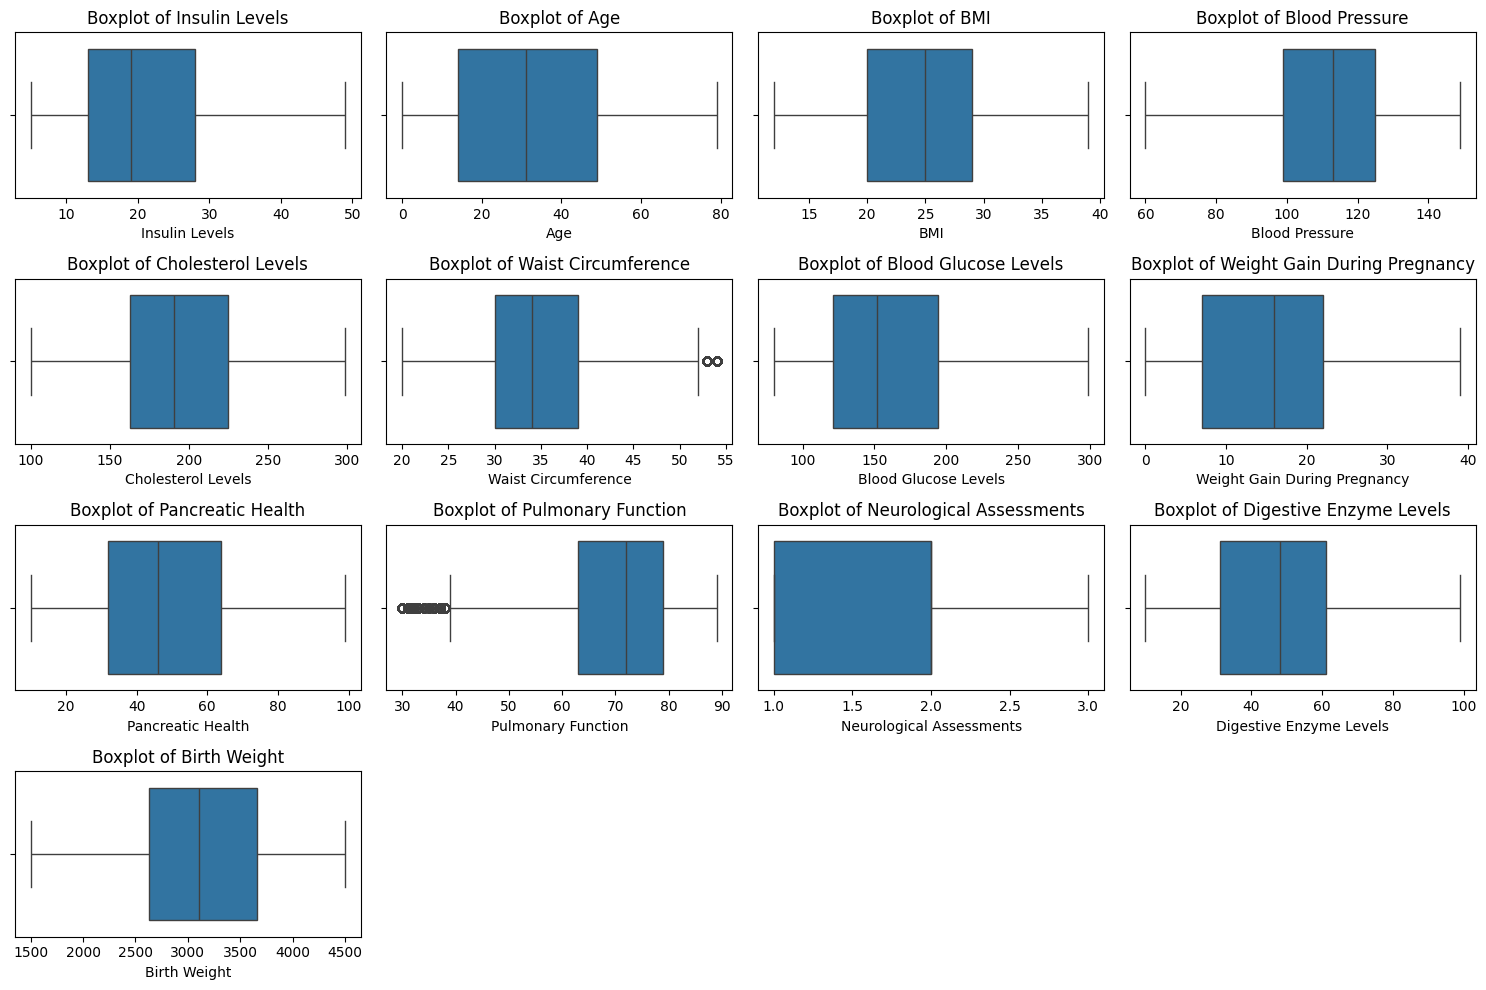

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include='number').columns

# Menentukan jumlah baris dan kolom subplot
num_cols = 4  # Misal 4 kolom
num_rows = (len(numeric_cols) // num_cols) + 1  # Sesuaikan baris berdasarkan jumlah kolom

# Membuat grid untuk subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 10))


# Menyesuaikan grid dengan kolom numerik
for i, col in enumerate(numeric_cols):
    ax = axes[i // num_cols, i % num_cols]  # Menentukan posisi subplot
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f'Boxplot of {col}')

# Menghapus sisa subplot yang tidak terpakai
for j in range(i + 1, num_rows * num_cols):
    fig.delaxes(axes[j // num_cols, j % num_cols])

# Menyesuaikan tampilan
plt.tight_layout()
plt.show()

Menangani Outlier

In [47]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f'{column} - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}')
    print(f'Removing values outside [{lower_bound}, {upper_bound}]')

    # Menghapus baris dengan nilai outlier
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Hapus outlier untuk dua kolom
df_cleaned = remove_outliers_iqr(df, 'Waist Circumference')
df_cleaned = remove_outliers_iqr(df_cleaned, 'Pulmonary Function')
df_cleaned = remove_outliers_iqr(df_cleaned, 'Blood Pressure')

# Menampilkan jumlah data setelah dibersihkan
print(f"Jumlah data setelah penghapusan outlier: {len(df_cleaned)}")

Waist Circumference - Q1: 30.0, Q3: 39.0, IQR: 9.0
Removing values outside [16.5, 52.5]
Pulmonary Function - Q1: 63.0, Q3: 79.0, IQR: 16.0
Removing values outside [39.0, 103.0]
Blood Pressure - Q1: 100.0, Q3: 125.0, IQR: 25.0
Removing values outside [62.5, 162.5]
Jumlah data setelah penghapusan outlier: 67438


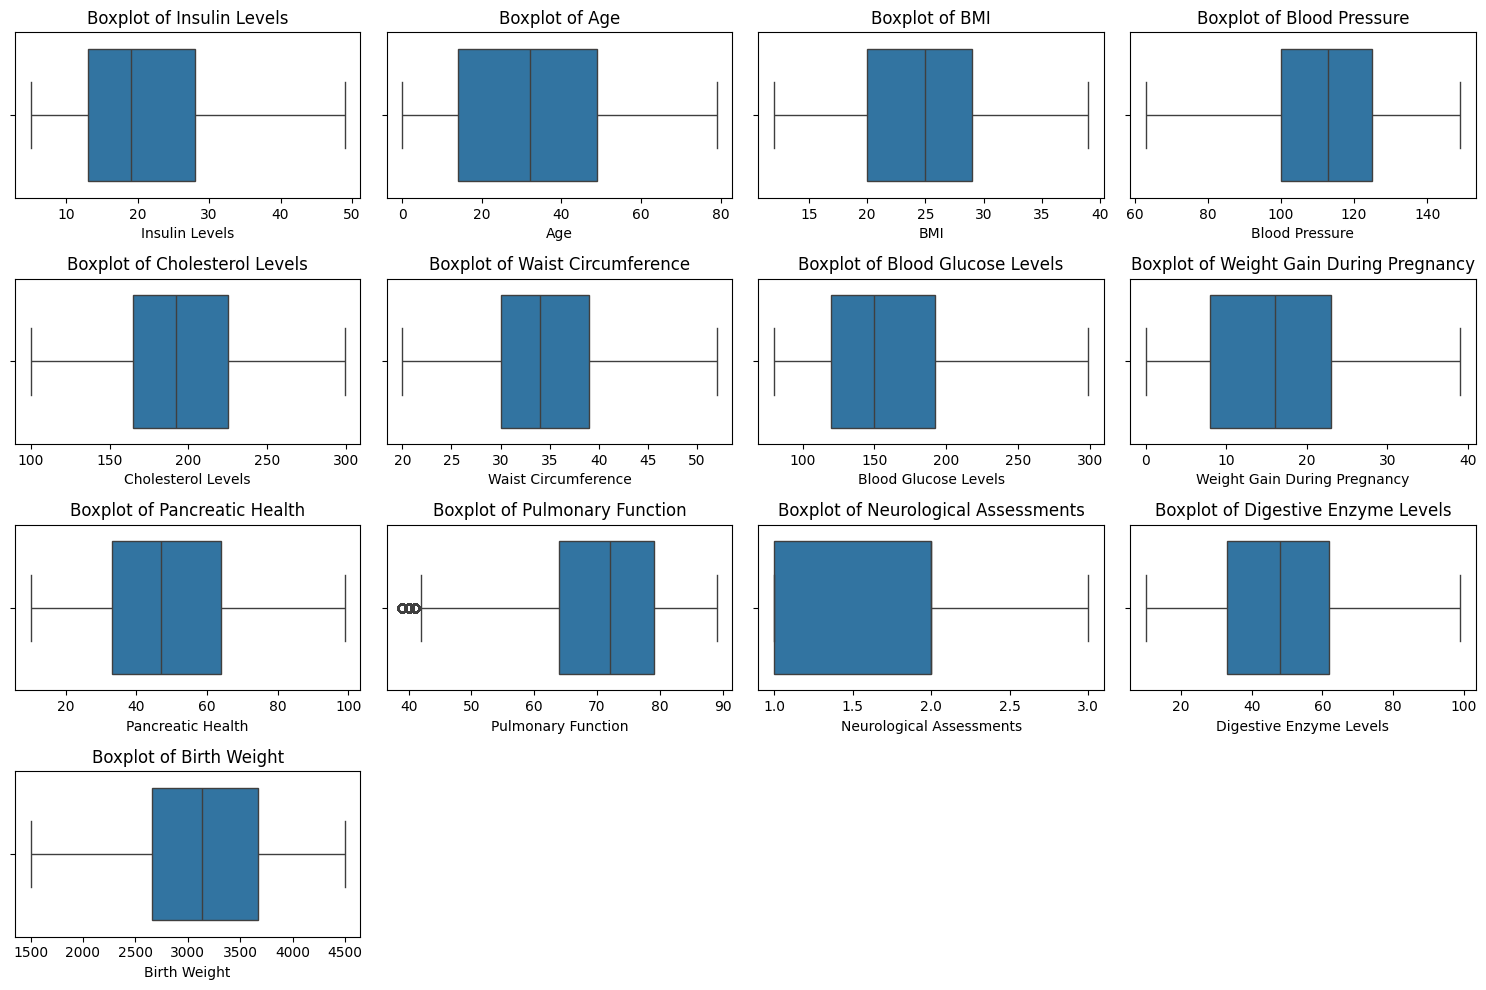

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df_cleaned.select_dtypes(include='number').columns

# Menentukan jumlah baris dan kolom subplot
num_cols = 4  # Misal 4 kolom
num_rows = (len(numeric_cols) // num_cols) + 1  # Sesuaikan baris berdasarkan jumlah kolom

# Membuat grid untuk subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 10))


# Menyesuaikan grid dengan kolom numerik
for i, col in enumerate(numeric_cols):
    ax = axes[i // num_cols, i % num_cols]  # Menentukan posisi subplot
    sns.boxplot(x=df_cleaned[col], ax=ax)
    ax.set_title(f'Boxplot of {col}')

# Menghapus sisa subplot yang tidak terpakai
for j in range(i + 1, num_rows * num_cols):
    fig.delaxes(axes[j // num_cols, j % num_cols])

# Menyesuaikan tampilan
plt.tight_layout()
plt.show()


### Melakukan Kategorisasi

In [49]:
numerical_cols = ['Insulin Levels', 'Age', 'BMI', 'Blood Pressure', 'Cholesterol Levels', 
                  'Waist Circumference', 'Blood Glucose Levels', 'Weight Gain During Pregnancy', 
                  'Pancreatic Health', 'Pulmonary Function', 'Neurological Assessments', 
                  'Digestive Enzyme Levels', 'Birth Weight']

# Label biner (1 = Diabetes, 0 = Bukan Diabetes (Pra_Diabetic))
diabetes_labels = [
    'Type 1 Diabetes',
    'Type 2 Diabetes',
    'Gestational Diabetes',
    'MODY',
    'LADA',
    'Neonatal Diabetes Mellitus (NDM)',
    'Wolfram Syndrome',
    'Steroid-Induced Diabetes',
    'Cystic Fibrosis-Related Diabetes (CFRD)',
    'Type 3c Diabetes (Pancreatogenic Diabetes)',
    'Wolcott-Rallison Syndrome',
    'Secondary Diabetes'
]

df_cleaned['Is_Diabetic'] = df_cleaned['Target'].apply(lambda x: 1 if x in diabetes_labels else 0)
df_cleaned.drop('Target', axis=1, inplace=True)

### Melakukan Encoding

In [50]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

label_encode_cols = [
    'Socioeconomic Factors', 'Alcohol Consumption', 'Physical Activity', 'Glucose Tolerance Test', 'Liver Function Tests', 'Pancreatic Health'
]

one_hot_encode_cols = [
    'Genetic Markers', 'Autoantibodies', 'Family History',
    'Dietary Habits',
    'Environmental Factors', 'Ethnicity', 'Smoking Status',
    'History of PCOS', 'Previous Gestational Diabetes', 'Pregnancy History',
    'Cystic Fibrosis Diagnosis', 'Steroid Use History',
    'Genetic Testing', 'Urine Test', 'Early Onset Symptoms'
]

le = LabelEncoder()
for col in label_encode_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col])

df_cleaned = pd.get_dummies(df_cleaned, columns=one_hot_encode_cols, drop_first=True)

# Ubah semua kolom boolean jadi 0 dan 1
df_cleaned = df_cleaned.astype({col: int for col in df_cleaned.columns if df_cleaned[col].dtype == 'bool'})

print(df_cleaned.head())

   Insulin Levels  Age  BMI  Physical Activity  Blood Pressure  \
0              40   44   38                  0             124   
1              13    1   17                  0              73   
2              27   36   24                  0             121   
3               8    7   16                  1             100   
4              17   10   17                  0             103   

   Cholesterol Levels  Waist Circumference  Blood Glucose Levels  \
0                 201                   50                   168   
1                 121                   24                   178   
2                 185                   36                   105   
3                 151                   29                   121   
4                 146                   33                   289   

   Socioeconomic Factors  Alcohol Consumption  ...  History of PCOS_Yes  \
0                      2                    0  ...                    0   
1                      0                    

# DATA MODELLING

### SCALING DI DATA PREPROCESSING / PREPERATION

In [51]:
# from sklearn.preprocessing import StandardScaler
# X = df_cleaned[numerical_cols]
# y = df_cleaned.drop(numerical_cols, axis=1)

# scaler = StandardScaler()

# df_cleaned = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# df_cleaned = pd.concat([df_cleaned, y.reset_index(drop=True)],axis=1)

**Balancing**

In [52]:
print(df_cleaned['Is_Diabetic'].value_counts())


Is_Diabetic
1    62062
0     5376
Name: count, dtype: int64


In [53]:
# from imblearn.over_sampling import SMOTE

# X = df_cleaned.drop('Is_Diabetic', axis=1)
# y = df_cleaned['Is_Diabetic']

# # smote = SMOTE(random_state=42)
# # X_balanced, y_balanced = smote.fit_resample(X, y)

# # print(y_balanced.value_counts())

# **Logistic Regression**

## Splitting data

In [54]:
X = df_cleaned.drop('Is_Diabetic', axis=1)
y = df_cleaned['Is_Diabetic']

In [55]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67438 entries, 0 to 69999
Data columns (total 35 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Insulin Levels                     67438 non-null  int64
 1   Age                                67438 non-null  int64
 2   BMI                                67438 non-null  int64
 3   Physical Activity                  67438 non-null  int64
 4   Blood Pressure                     67438 non-null  int64
 5   Cholesterol Levels                 67438 non-null  int64
 6   Waist Circumference                67438 non-null  int64
 7   Blood Glucose Levels               67438 non-null  int64
 8   Socioeconomic Factors              67438 non-null  int64
 9   Alcohol Consumption                67438 non-null  int64
 10  Glucose Tolerance Test             67438 non-null  int64
 11  Weight Gain During Pregnancy       67438 non-null  int64
 12  Pancreatic Health      

In [56]:
#80% train dan 20% test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Scaling**

In [57]:
from sklearn.preprocessing import StandardScaler

# 1. Pisahkan kolom numerik & non-numerik
X_numerical = X_train[numerical_cols]
X_non_numerical = X_train.drop(columns=numerical_cols)

# 2. Scale hanya yang numerik
scaler_logistic = StandardScaler()
X_numerical_scaled = pd.DataFrame(
    scaler_logistic.fit_transform(X_numerical),
    columns=numerical_cols,
    index=X_numerical.index
)

# 3. Gabungkan lagi
X_train_scaled = pd.concat([X_numerical_scaled, X_non_numerical], axis=1)
all_columns = X_train_scaled.columns.tolist()

# Pisahkan dulu test set
X_test_numerical = X_test[numerical_cols]
X_test_non_numerical = X_test.drop(columns=numerical_cols)

# Transform hanya kolom numerik
X_test_numerical_scaled = pd.DataFrame(
    scaler_logistic.transform(X_test_numerical),
    columns=numerical_cols,
    index=X_test.index
)

# Gabungkan lagi
X_test_scaled = pd.concat([X_test_numerical_scaled, X_test_non_numerical], axis=1)

**BALANCING**

In [58]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42, sampling_strategy=0.5)  # rasio minor:mayor 1:2
X_resampled, y_resampled = rus.fit_resample(X_train_scaled, y_train)

In [59]:
X_resampled

,Insulin Levels,Age,BMI,Blood Pressure,Cholesterol Levels,Waist Circumference,Blood Glucose Levels,Weight Gain During Pregnancy,Pancreatic Health,Pulmonary Function,...,History of PCOS_Yes,Previous Gestational Diabetes_Yes,Pregnancy History_Normal,Cystic Fibrosis Diagnosis_Yes,Steroid Use History_Yes,Genetic Testing_Positive,Urine Test_Ketones Present,Urine Test_Normal,Urine Test_Protein Present,Early Onset Symptoms_Yes
21804,-0.908152,0.974866,0.174730,0.822291,-0.089886,-0.023439,-0.953774,0.962861,0.546124,1.625873,...,1,0,1,1,1,0,0,1,0,1
27990,0.019004,0.448317,0.510834,0.407307,-0.067155,-0.326828,-0.784281,-0.505139,-0.665202,1.265085,...,0,0,1,0,1,0,0,1,0,1
64989,-0.259143,0.496185,0.342782,0.511053,0.319276,0.431645,-0.890214,0.753146,0.748011,0.363114,...,0,1,0,1,1,1,0,0,0,0
15538,0.204435,0.544053,0.174730,0.044196,0.955751,0.279951,-1.208014,-0.190568,0.192820,0.363114,...,1,0,1,1,0,0,1,0,0,0
533,-0.722721,0.544053,0.342782,0.666672,-0.158080,0.583340,-0.741908,1.172575,0.445180,1.535676,...,0,1,1,1,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13155,0.389866,-1.035595,-1.001633,0.562926,-0.271736,-0.933607,-0.085123,-0.400282,0.697539,-0.087872,...,0,0,0,1,0,0,0,1,0,0
57408,-0.630005,0.017504,1.014990,-0.422660,0.864826,-0.781912,-0.890214,0.019146,0.192820,0.363114,...,0,0,1,1,0,0,0,0,1,1
12917,-0.259143,-0.891990,-0.833581,-0.526406,-0.885480,-0.933607,-1.186827,-1.134282,-0.665202,0.633705,...,1,0,1,1,1,1,0,1,0,1
21115,1.595168,1.980097,-0.329425,1.444767,1.569495,0.128256,1.842860,2.011432,0.848955,0.272917,...,1,0,1,1,1,1,1,0,0,1


In [60]:
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [61]:
print(y_resampled.value_counts())

Is_Diabetic
1    8560
0    4280
Name: count, dtype: int64


In [62]:
print("Distribusi Data latih:\n", y_resampled.value_counts())
print("Distribusi Data Uji:\n", y_test.value_counts())

Distribusi Data latih:
 Is_Diabetic
1    8560
0    4280
Name: count, dtype: int64
Distribusi Data Uji:
 Is_Diabetic
1    12392
0     1096
Name: count, dtype: int64


## Training Model

### Training menggunakan Logistic Regression

In [63]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_resampled, y_resampled)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [64]:
X_resampled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12840 entries, 21804 to 11250
Data columns (total 35 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Insulin Levels                     12840 non-null  float64
 1   Age                                12840 non-null  float64
 2   BMI                                12840 non-null  float64
 3   Blood Pressure                     12840 non-null  float64
 4   Cholesterol Levels                 12840 non-null  float64
 5   Waist Circumference                12840 non-null  float64
 6   Blood Glucose Levels               12840 non-null  float64
 7   Weight Gain During Pregnancy       12840 non-null  float64
 8   Pancreatic Health                  12840 non-null  float64
 9   Pulmonary Function                 12840 non-null  float64
 10  Neurological Assessments           12840 non-null  float64
 11  Digestive Enzyme Levels            12840 non-null  floa

In [65]:
y_pred = model.predict(X_test_scaled)

In [66]:
from sklearn.metrics import classification_report, confusion_matrix


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.46      0.85      0.60      1096
           1       0.99      0.91      0.95     12392

    accuracy                           0.91     13488
   macro avg       0.72      0.88      0.77     13488
weighted avg       0.94      0.91      0.92     13488



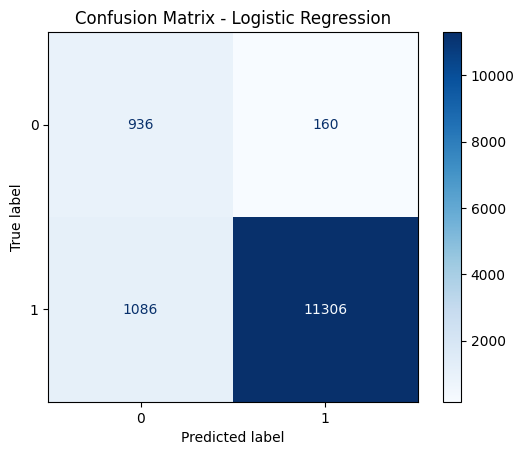

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Buat dan tampilkan confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

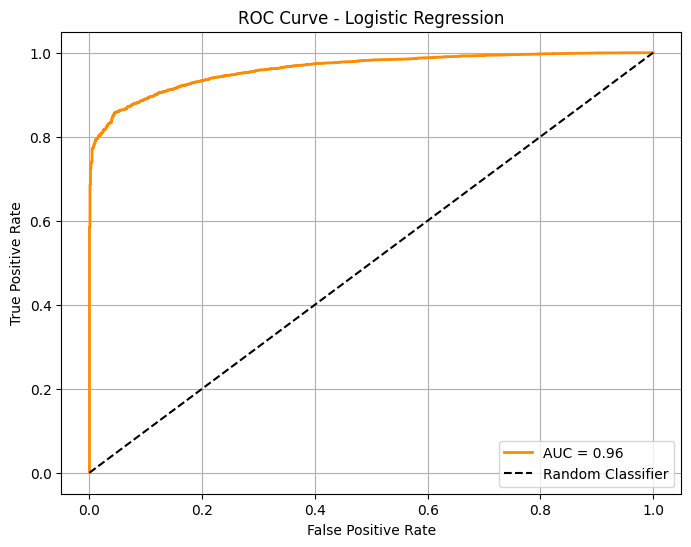

In [68]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Dapatkan probabilitas prediksi (bukan kelas, tapi probabilitas kelas 1)
y_probs = model.predict_proba(X_test_scaled)[:, 1]  # hanya ambil probabilitas untuk kelas 1 (Is_Diabetic=1)

# Hitung false positive rate, true positive rate, dan thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Hitung nilai AUC
auc_score = roc_auc_score(y_test, y_probs)

# Tampilkan ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}", color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


logreg_metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred)
}

# K-MEANS

## Feature Selection

In [70]:
unused = ['Pancreatic Health', 'Neurological Assessments']

df_kmean = df_cleaned[numerical_cols]
df_kmean = df_kmean.drop(unused, axis=1)


# from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score

# def compare_scalers(df_kmean, n_clusters=2):
#     scalers = {
#         'StandardScaler': StandardScaler(),
#         'MinMaxScaler': MinMaxScaler(),
#         'RobustScaler': RobustScaler(),
#         'PowerTransformer': PowerTransformer(method='yeo-johnson')
#     }

#     for name, scaler in scalers.items():
#         try:
#             df_scaled = scaler.fit_transform(df_kmean)
#             kmeans = KMeans(n_clusters=n_clusters, random_state=42)
#             labels = kmeans.fit_predict(df_scaled)
#             score = silhouette_score(df_scaled, labels)
#             print(f"{name}: Silhouette Score = {score:.4f}")
#         except Exception as e:
#             print(f"{name}: Error - {e}")

# compare_scalers(df_kmean, n_clusters=2)


**Scaling**

In [71]:
scaler_kmean = StandardScaler()
df_kmean_scaled = scaler_kmean.fit_transform(df_kmean)

df_kmean_scaled = pd.DataFrame(df_kmean_scaled, columns=df_kmean.columns)

### Import

In [72]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

### Elbow Method

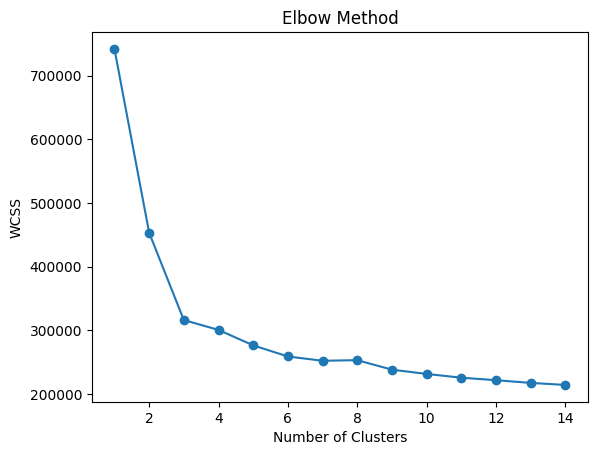

In [73]:
wcss = []

for i in range(1, 15):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_kmean_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.plot(range(1, 15), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

### Silhouette vs total cluster

In [74]:
# range_n_clusters = range(2, 5)
# silhouette_scores = []

# for n_clusters in range_n_clusters:
#     kmeans = KMeans(n_clusters=n_clusters, random_state=42)
#     cluster_labels = kmeans.fit_predict(df_kmean_scaled)
    
#     silhouette_avg = silhouette_score(df_kmean_scaled, cluster_labels)
#     silhouette_scores.append(silhouette_avg)
#     print(f"Cluster = {n_clusters} | Silhouette Score = {silhouette_avg:.3f}")

# # Visualisasi
# plt.figure(figsize=(8, 5))
# plt.plot(range_n_clusters, silhouette_scores, marker='o')
# plt.title("Silhouette Score vs Jumlah Cluster")
# plt.xlabel("Jumlah Cluster")
# plt.ylabel("Silhouette Score")
# plt.xticks(range_n_clusters)
# plt.grid(True)

### Modelling

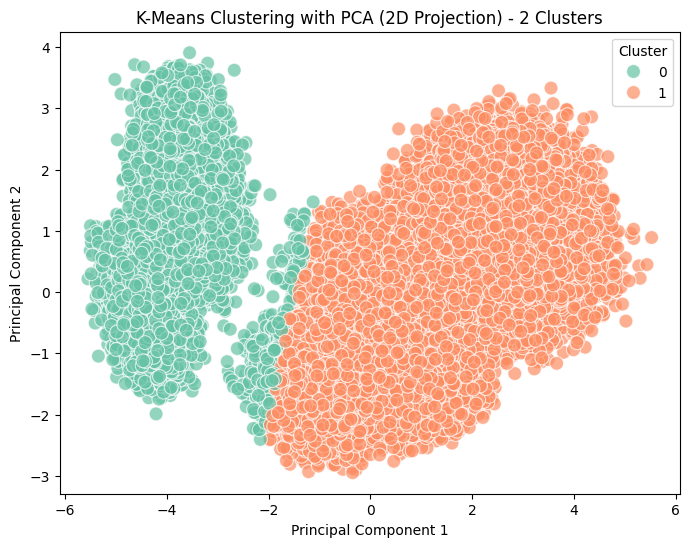

In [75]:
optimal_clusters = 2

# Melakukan clustering K-Means dengan jumlah klaster optimal
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
kmeans.fit(df_kmean_scaled)

# Menyimpan hasil klaster
labels = kmeans.labels_

# Menggunakan PCA untuk mereduksi dimensi data menjadi 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_kmean_scaled)

# Visualisasi hasil clustering dengan scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='Set2', s=100, alpha=0.7)
plt.title(f'K-Means Clustering with PCA (2D Projection) - {optimal_clusters} Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

### Evaluation

In [76]:
silhouette = silhouette_score(df_kmean_scaled, labels)

print(silhouette)

0.39324482478485273


In [77]:
from sklearn.metrics import silhouette_score

kmeans_metrics = {
    'silhouette': silhouette,
    'n_clusters': kmeans.n_clusters
}

## Lihat karakteristik cluster

In [78]:
# Salin data awal
df_with_clusters = df_kmean.copy()

# Tambahkan label cluster ke DataFrame
df_with_clusters['Cluster'] = labels

In [79]:
cluster_summary = df_with_clusters.groupby('Cluster').mean().T
display(cluster_summary)

Cluster,0,1
Insulin Levels,11.954623,24.548586
Age,6.865984,39.791069
BMI,18.213443,26.826592
Blood Pressure,87.342613,118.998011
Cholesterol Levels,144.034527,210.426766
Waist Circumference,27.949028,37.134361
Blood Glucose Levels,198.154487,148.017619
Weight Gain During Pregnancy,3.090072,19.357520
Pulmonary Function,58.241556,74.542353
Digestive Enzyme Levels,20.273695,54.688479


## SAve model


In [80]:
# --- Import dulu semua yang dibutuhin ---
import joblib

# === SAVE LOGISTIC REGRESSION MODEL ===
joblib.dump(model, 'logreg_model.pkl')   # ganti logreg_model sesuai nama model di notebook kamu
joblib.dump(scaler_logistic, 'scaler_logistic.pkl')
joblib.dump(all_columns, 'model_columns.pkl')
# Save list of numerical columns
joblib.dump(X_numerical, 'numerical_columns.pkl')

# === SAVE KMEANS CLUSTERING MODEL ===
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler_kmean, 'scaler_kmeans.pkl')

all_metrics = {
    'logreg': logreg_metrics,
    'kmeans': kmeans_metrics
}

# Simpan ke file .pkl
joblib.dump(all_metrics, 'metrics.pkl')

# Done!
print("Semua model udah disave jadi file .pkl")


Semua model udah disave jadi file .pkl


## Streamlit

In [87]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load model dan scaler
logreg_model = joblib.load('logreg_model.pkl')
kmeans_model = joblib.load('kmeans_model.pkl')
scaler_kmean = joblib.load('scaler_kmeans.pkl')
scaler_logistic = joblib.load('scaler_logistic.pkl')
numerical_cols = joblib.load('numerical_columns.pkl')
all_columns = joblib.load('model_columns.pkl')

cluster_stats = {
    0: {
        "label": "Kelompok Usia Muda, Risiko Metabolik Dini",
        "deskripsi": "Cluster ini ditandai dengan usia yang sangat muda, berat badan rendah, namun memiliki tingkat gula darah yang tinggi dan fungsi paru yang cenderung rendah.",
        "Age": -1.25,  # Contoh Z-score (rata-rata usia di bawah rata-rata keseluruhan)
        "Blood Pressure": -0.85 # Contoh Z-score (rata-rata tekanan darah di bawah rata-rata keseluruhan)
    },
    1: {
        "label": "Kelompok Dewasa, Risiko Metabolik Tinggi",
        "deskripsi": "Cluster ini berisi individu dewasa dengan BMI, kolesterol, tekanan darah, dan lingkar pinggang yang tinggi, menunjukkan risiko sindrom metabolik.",
        "Age": 1.10, # Contoh Z-score (rata-rata usia di atas rata-rata keseluruhan)
        "Blood Pressure": 1.50 # Contoh Z-score (rata-rata tekanan darah di atas rata-rata keseluruhan)
    }
}

# Fitur yang digunakan
feature_columns = [
    'Insulin Levels', 'Age', 'BMI', 'Physical Activity', 'Blood Pressure',
    'Cholesterol Levels', 'Waist Circumference', 'Blood Glucose Levels',
    'Socioeconomic Factors', 'Alcohol Consumption', 'Glucose Tolerance Test',
    'Weight Gain During Pregnancy', 'Pancreatic Health', 'Pulmonary Function',
    'Neurological Assessments', 'Liver Function Tests', 'Digestive Enzyme Levels',
    'Birth Weight', 'Genetic Markers_Positive', 'Autoantibodies_Positive',
    'Family History_Yes', 'Dietary Habits_Unhealthy', 'Environmental Factors_Present',
    'Ethnicity_Low Risk', 'Smoking Status_Smoker', 'History of PCOS_Yes',
    'Previous Gestational Diabetes_Yes', 'Pregnancy History_Normal',
    'Cystic Fibrosis Diagnosis_Yes', 'Steroid Use History_Yes',
    'Genetic Testing_Positive', 'Urine Test_Ketones Present', 'Urine Test_Normal',
    'Urine Test_Protein Present', 'Early Onset Symptoms_Yes'
]

numerical_cols = ['Insulin Levels', 'Age', 'BMI', 'Blood Pressure', 'Cholesterol Levels', 
                  'Waist Circumference', 'Blood Glucose Levels', 'Weight Gain During Pregnancy', 
                  'Pancreatic Health', 'Pulmonary Function', 'Neurological Assessments', 
                  'Digestive Enzyme Levels', 'Birth Weight']

# UI layout
st.set_page_config(page_title="Prediksi Kesehatan", layout="wide")
tab1, tab2, tab3 = st.tabs(["🧑‍⚕️ Tenaga Medis (Batch CSV)", "👤 Masyarakat Umum (Manual Input)", "📊 Model Performance"])

# =======================
# TAB 1 - TENAGA MEDIS
# =======================
with tab1:
    st.title("🧑‍⚕️ Upload Data CSV - Untuk Tenaga Medis")

    uploaded_file = st.file_uploader("Upload file CSV berisi data pasien", type=["csv"])
    
    if uploaded_file:
        df = pd.read_csv(uploaded_file)
        st.write("📋 Data yang diupload", df.head())

        if st.button("🔍 Prediksi Pasien"):
            # ===============================
            # 1️⃣ PREDIKSI DIABETES - LOGREG
            # ===============================
            df_numerical = df[numerical_cols]
            df_non_numerical = df.drop(columns=numerical_cols)

            df_numerical_scaled = pd.DataFrame(
                scaler_logistic.transform(df_numerical),
                columns=numerical_cols,
                index=df.index
            )

            df_scaled_logreg = pd.concat([df_numerical_scaled, df_non_numerical], axis=1)
            df_scaled_logreg = df_scaled_logreg[all_columns]

            diabetes_pred = logreg_model.predict(df_scaled_logreg)

            try:
                probs = logreg_model.predict_proba(df_scaled_logreg)
                prob_df = pd.DataFrame(probs, columns=[f"Probabilitas_Diabetes_{i}" for i in range(probs.shape[1])])
            except:
                prob_df = pd.DataFrame()

            # ===============================
            # 2️⃣ CLUSTERING DIABETES - KMEANS
            # ===============================
            kmeans_features = ['Insulin Levels', 'Age', 'BMI', 'Blood Pressure',
                            'Cholesterol Levels', 'Waist Circumference', 'Blood Glucose Levels',
                            'Weight Gain During Pregnancy', 'Pulmonary Function',
                            'Digestive Enzyme Levels', 'Birth Weight']

            df_kmeans_input = df[kmeans_features]
            df_kmeans_scaled = scaler_kmean.transform(df_kmeans_input)
            cluster_labels = kmeans_model.predict(df_kmeans_scaled)

            # Gabung hasil prediksi
            df_result = df.copy()
            df_result["Prediksi_Diabetes"] = diabetes_pred
            if not prob_df.empty:
                df_result = pd.concat([df_result, prob_df], axis=1)
            df_result["Cluster"] = cluster_labels

            st.write("### 🔎 Hasil Prediksi Pasien:")

            for idx, row in df_result.iterrows():
                diabetes = "Berpotensi Diabetes" if row["Prediksi_Diabetes"] == 1 else "Berpotensi Tidak Diabetes"
                cluster = int(row["Cluster"])
                
                # Probabilitas jika tersedia
                if "Probabilitas_Diabetes_1" in row:
                    prob = round(row["Probabilitas_Diabetes_1"] * 100, 2)
                    prob_text = f"Probabilitas terkena diabetes: **{prob}%**"
                else:
                    prob_text = "Probabilitas tidak tersedia"

                # Insight Cluster
                if cluster == 0:
                    cluster_info = """
                    **Cluster 0** → *Kelompok Usia Muda, Risiko Metabolik Dini*:
                    - Usia muda, berat badan rendah
                    - Gula darah tinggi, fungsi paru rendah
                    """
                elif cluster == 1:
                    cluster_info = """
                    **Cluster 1** → *Kelompok Dewasa, Risiko Metabolik Tinggi*:
                    - Usia dewasa, BMI dan kolesterol tinggi
                    - Tekanan darah dan lingkar pinggang besar
                    """

                # Tampilkan hasil untuk setiap pasien
                st.markdown(f"""
                ---
                ### 🧍 Pasien {idx+1}
                - Prediksi: **{diabetes}**
                - {prob_text}
                - Termasuk: {cluster_info}
                """)


# =======================
# TAB 2 - MASYARAKAT UMUM
# =======================
with tab2:
    st.title("👤 Input Manual - Untuk Masyarakat Umum")
    st.write("Silakan isi data numerik berikut:")

    insulin = st.number_input(
    "Tingkat Insulin (0-300 μU/mL)", 
    help="Insulin membantu mengatur kadar gula darah. Nilai normal biasanya antara 2–25 μU/mL.",
    min_value=0, max_value=300, value=100
    )

    age = st.number_input(
        "Umur Anda (tahun)", 
        help="Masukkan umur Anda dalam tahun.",
        min_value=1, max_value=100, value=30
    )

    bmi = st.number_input(
        "Indeks Massa Tubuh (BMI)", 
        help="BMI adalah indikator berat badan ideal berdasarkan tinggi badan. Rentang normal: 18.5–24.9",
        min_value=10, max_value=60, value=22
    )

    bp = st.number_input(
        "Tekanan Darah (mmHg)", 
        help="Masukkan tekanan darah sistolik (angka atas). Normal: sekitar 120 mmHg.",
        min_value=60, max_value=180, value=120
    )

    chol = st.number_input(
        "Kadar Kolesterol Total (mg/dL)", 
        help="Kolesterol tinggi bisa meningkatkan risiko penyakit jantung. Normal: < 200 mg/dL.",
        min_value=100, max_value=400, value=200
    )

    waist = st.number_input(
        "Lingkar Pinggang (cm)", 
        help="Lingkar pinggang tinggi bisa menunjukkan risiko penyakit metabolik.",
        min_value=50, max_value=150, value=85
    )

    glucose = st.number_input(
        "Tingkat Gula Darah (mg/dL)", 
        help="Masukkan kadar gula darah puasa Anda. Normal: 70–100 mg/dL.",
        min_value=50, max_value=300, value=100
    )

    weight_gain = st.number_input(
        "Penambahan Berat Badan Saat Hamil (kg)", 
        help="Masukkan 0 jika Anda tidak sedang hamil. Kenaikan normal saat hamil: 11–16 kg.",
        min_value=0, max_value=30, value=10
    )

    pulmonary = st.number_input(
        "Fungsi Paru-Paru (skor PFT)", 
        help="Didapat dari Pulmonary Function Test. Skor 100 dianggap normal.",
        min_value=50, max_value=150, value=90
    )

    enzyme = st.number_input(
        "Tingkat Enzim Pencernaan", 
        help="Menunjukkan seberapa baik tubuh mencerna makanan. Skor 50–100 biasanya menunjukkan fungsi baik.",
        min_value=0, max_value=100, value=50
    )

    birth_weight = st.number_input(
        "Berat Badan Saat Lahir (gram)", 
        help="Normal: 2500–4000 gram. Berat lahir bisa memengaruhi risiko penyakit metabolik di masa depan.",
        min_value=1000, max_value=5000, value=3000
    )



    input_vector = np.array([
        insulin, age, bmi, bp, chol,
        waist, glucose, weight_gain,
        pulmonary, enzyme, birth_weight
    ]).reshape(1, -1)

    scaled_input = scaler_kmean.transform(input_vector)

    if st.button("🔍 Prediksi"):
        cluster = kmeans_model.predict(scaled_input)[0]
        st.success(f"Hasil Prediksi: Anda masuk ke **Cluster {cluster}**")

        if cluster == 0:
            st.markdown("""
            ### 🧬 Karakteristik Cluster 0 - *Kelompok Usia Muda, Risiko Metabolik Dini*
            - Umumnya Berusia **sangat muda (anak-anak/remaja)**.
            - Umumnya **Berat badan dan BMI rendah**, cenderung kurus.
            - Umumnya **Gula darah sangat tinggi**.
            - Umumnya **Fungsi paru dan enzim pencernaan rendah**.
            - Umumnya **Berat lahir rendah**, underweight saat kelahiran.
            
            ⚠️ **Saran**: Lakukan pemeriksaan lanjutan untuk gula darah dan metabolisme, terutama jika pasien masih anak-anak.
            """)
        elif cluster == 1:
            st.markdown("""
            ### 🧬 Karakteristik Cluster 1 - *Kelompok Dewasa, Risiko Metabolik Tinggi*
            - Umumnya Berusia **dewasa** dengan kecenderungan overweight (*BMI tinggi*).
            - Umumnya **Tekanan darah, kolesterol, dan lingkar pinggang tinggi** → berisiko *sindrom metabolik*.
            - Umumnya **Gula darah tinggi**, walau tidak setinggi Cluster 0.
            - Umumnya **Berat lahir normal**, fungsi paru dan pencernaan lebih baik.

            ⚠️ **Saran**: Jaga pola makan, olahraga teratur, dan lakukan cek rutin kolesterol/gula darah untuk mencegah komplikasi.
            """)
with tab3:
    st.subheader("Performance Model")
    col1, col2 = st.columns(2)
    
    with col1:
        st.markdown("**Logistic Regression**")
        st.metric("Accuracy", "93%")
        st.metric("Precision", "91%")
        st.metric("Recall", "95%")
    
    with col2:
        st.markdown("**K-Means Clustering**")
        st.metric("Silhouette Score", "0.40")
        st.metric("Jumlah Cluster", "2")
        
        st.markdown("**Karakteristik Cluster**")
        selected_cluster = st.selectbox("Pilih Cluster", [0, 1, 2])
        st.write(f"Label: {cluster_stats[selected_cluster]['label']}")
        st.write(cluster_stats[selected_cluster]['deskripsi'])
        st.write("Parameter Z-Score:")
        st.write(f"- Usia: {cluster_stats[selected_cluster]['Age']:.2f}")
        st.write(f"- Tekanan Darah: {cluster_stats[selected_cluster]['Blood Pressure']:.2f}")


Overwriting app.py


In [84]:
from pyngrok import ngrok
import threading
import time
import os

In [ ]:
!ngrok config add-authtoken your_ngrok_auth_token

                                                                                                    
Installing ngrok ... 
                                                                                                    
Authtoken saved to configuration file: C:\Users\Zidd\AppData\Local/ngrok/ngrok.yml


In [ ]:
def run_streamlit():
    os.system("streamlit run app.py --server.port 8501")

thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()

time.sleep(5)

public_url = ngrok.connect(addr=8501)
print(f"Streamlit app is live at: {public_url}")


Streamlit app is live at: NgrokTunnel: "https://be0b828f621a.ngrok-free.app" -> "http://localhost:8501"


t=2025-10-19T22:18:52+0700 lvl=warn msg="failed to open private leg" id=f96ea2570d12 privaddr=localhost:8501 err="dial tcp [::1]:8501: connectex: No connection could be made because the target machine actively refused it."
t=2025-10-19T22:18:54+0700 lvl=warn msg="failed to open private leg" id=79a9b5ae9457 privaddr=localhost:8501 err="dial tcp [::1]:8501: connectex: No connection could be made because the target machine actively refused it."
t=2025-10-19T22:36:49+0700 lvl=warn msg="failed to open private leg" id=f28d44cd0213 privaddr=localhost:8501 err="dial tcp [::1]:8501: connectex: No connection could be made because the target machine actively refused it."
t=2025-10-19T22:36:50+0700 lvl=warn msg="failed to open private leg" id=734efbf2e40a privaddr=localhost:8501 err="dial tcp [::1]:8501: connectex: No connection could be made because the target machine actively refused it."
